# 3b. Time-to-Clean Prediction

**Purpose:** turn the `3a` Q-duty deviation signal into "how many days until
this HX needs cleaning", per HX, so `3c` can build a 1-year schedule.
(`3a` was switched from a `cold_out`-temperature target to `Q` duty (kW),
per user decision, to stay consistent with `2b`'s existing Q-based
methodology -- all deviation/threshold/rate values below are now in kW, not
degC.)

**Threshold definition (per user decision, data-driven):** for each HX,
the clean-trigger threshold is the **peak deviation observed immediately
before its own historical clean events** (`event_type in {SWITCH, TAM}` --
`DATA_START` is not a real clean, just where the dataset begins). This is
the level operators/engineers actually let fouling reach before acting, so
it's the plant's own revealed threshold rather than an arbitrary % figure.
For HX with **no** observed real-clean event in this dataset, there's no
self-threshold to read -- fall back to the median self-threshold of HX in
the same `2d` group (CPHT-1/CPHT-2), since that's the only physically
grounded peer group available.

**Rate estimation:** linear slope of deviation vs. `days_on_duty` within the
*current* (still-open) run. If the current run is too short to fit
reliably, fall back to the slope of the HX's own most recent *completed*
run.

**TAM constraint (per user decision):** the next turnaround is **~2028
(placeholder `2028-06-01` -- confirm exact date before using this for
scheduling decisions)**. HX classified `TAM_ONLY` in `2d` cannot be cleaned
before that date regardless of projected need -- this notebook flags those
cases as "at risk before next TAM" rather than silently ignoring the
infeasibility.

In [1]:
import sys
sys.path.append('C:/Desktop/Bangchak Internship 2026/furnace-optimization/notebooks')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from cpht_config import CPHT_1_HX, CPHT_2_HX

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

FIG_DIR = r'C:\Desktop\Bangchak Internship 2026\furnace-optimization\figures\features'
os.makedirs(FIG_DIR, exist_ok=True)
DATA_DIR = r'C:\Desktop\Bangchak Internship 2026\Data'

dev = pd.read_csv(DATA_DIR + r'\Q_Deviation_Signal.csv', parse_dates=['Timestamp'])
AS_OF_DATE = dev['Timestamp'].max()
print(f'"Now" reference (last available data point): {AS_OF_DATE.date()}')

# Effort tiers -- SINGLE SOURCE: bypass_config.py, parsed from the real plant file
# (Data/list bypass Cleaning Heat Exchanger.xlsx). 2026-07-12 fix: the old hardcoded
# lists here directly contradicted that file (see bypass_config.py docstring).
from bypass_config import BYPASS_CONFIG
from cpht_config import PARALLEL_SHELL_GROUPS
_SWAP = {a for pair in PARALLEL_SHELL_GROUPS for a in pair}

def effort_tier(hx):
    if hx in _SWAP:
        return 'SWAP_CAPABLE'
    mode = BYPASS_CONFIG.get(hx, {}).get('online_mode', 'none')
    return {'full': 'ONLINE_FULL', 'partial': 'ONLINE_PARTIAL', 'none': 'TAM_ONLY'}[mode]

NEXT_TAM_DATE = pd.Timestamp('2028-06-01')  # PLACEHOLDER -- confirm exact date before scheduling on this
print(f'Next TAM (placeholder): {NEXT_TAM_DATE.date()} -- confirm exact date before using for scheduling')

"Now" reference (last available data point): 2026-07-01


Next TAM (placeholder): 2028-06-01 -- confirm exact date before using for scheduling


## 1. Historical Clean-Trigger Thresholds

A real clean event is a run boundary where the *new* run's `event_type` is
`SWITCH` or `TAM`. The trigger level is the deviation on the last day of the
*preceding* run (the peak fouling state right before it was reset).

**Reliability check added after first pass:** several HX show clean events
with a **negative** trigger deviation (model shows no fouling signal at the
moment of the "clean") -- e.g. E112AB ranges from -15.1 to +4.5 across just
4 events, E104's two events are -11.4 and +2.2. A clean happening while the
model shows no positive fouling buildup is very likely a **non-fouling-driven
shell swap** (spare rotation, e.g. the documented E113A<->E112C pair),
not evidence that "slightly fouled" is an acceptable trigger level. Using
those events as-is would produce a threshold below the HX's current healthy
operating deviation, which is exactly what happened in the first pass (8 of
15 HX showed `days_to_threshold = 0` immediately).

**Fix:** only positive trigger deviations are treated as fouling-driven
clean-trigger evidence. HX with zero positive trigger events fall back to
the group median of *other* HX that do have at least one positive trigger
event.

In [2]:
trigger_rows = []
for hx, g in dev.groupby('HX'):
    g = g.sort_values('Timestamp').reset_index(drop=True)
    run_change = g['run_id'] != g['run_id'].shift(1)
    real_clean_starts = g[run_change & g['event_type'].isin(['SWITCH', 'TAM'])]
    for idx in real_clean_starts.index:
        if idx == 0:
            continue
        trigger_rows.append({'HX': hx, 'clean_date': g.loc[idx, 'Timestamp'],
                              'trigger_deviation': g.loc[idx - 1, 'deviation']})

triggers = pd.DataFrame(trigger_rows)
triggers['fouling_driven'] = triggers['trigger_deviation'] > 0

reliability = triggers.groupby('HX').agg(
    n_total=('trigger_deviation', 'count'),
    n_positive=('fouling_driven', 'sum'),
)
reliability['pct_non_fouling_driven'] = 1 - reliability['n_positive'] / reliability['n_total']
self_threshold = (triggers[triggers['fouling_driven']]
                   .groupby('HX')['trigger_deviation'].median().rename('self_threshold'))

print(f'{len(triggers)} historical real-clean events across {reliability.shape[0]} HX '
      f'({triggers["fouling_driven"].sum()} classified fouling-driven, i.e. positive deviation)')
reliability.join(self_threshold).sort_values('pct_non_fouling_driven', ascending=False)

94 historical real-clean events across 15 HX (67 classified fouling-driven, i.e. positive deviation)


,n_total,n_positive,pct_non_fouling_driven,self_threshold
HX,,,,
E101CD,3,1,0.666667,474.667671
E105AB,3,1,0.666667,1855.592320
E106AB,5,2,0.600000,896.958581
E109AB,7,3,0.571429,652.768646
E108AB,6,3,0.500000,489.675809
E107AB,16,11,0.312500,608.349894
E112AB,10,7,0.300000,679.472219
E103AB,8,6,0.250000,657.439449
E102,6,5,0.166667,322.399998


In [3]:
all_hx = dev['HX'].unique()
group_of = {hx: ('CPHT-1' if hx in CPHT_1_HX else 'CPHT-2') for hx in all_hx}
group_median = self_threshold.rename_axis('HX').reset_index()
group_median['group'] = group_median['HX'].map(group_of)
group_median = group_median.groupby('group')['self_threshold'].median()

threshold_rows = []
for hx in all_hx:
    n_pos = reliability['n_positive'].get(hx, 0)
    if hx in self_threshold.index:
        conf = 'high' if n_pos >= 3 else 'medium'
        threshold_rows.append({'HX': hx, 'threshold': self_threshold[hx],
                                'threshold_source': 'own_history', 'threshold_confidence': conf,
                                'n_fouling_driven_events': int(n_pos)})
    else:
        grp = group_of[hx]
        threshold_rows.append({'HX': hx, 'threshold': group_median[grp],
                                'threshold_source': f'{grp}_group_median (no own fouling-driven clean observed)',
                                'threshold_confidence': 'low', 'n_fouling_driven_events': int(n_pos)})
threshold_df = pd.DataFrame(threshold_rows)
threshold_df.sort_values('threshold_confidence')

,HX,threshold,threshold_source,threshold_confidence,n_fouling_driven_events
3,E102,322.399998,own_history,high,5
4,E103AB,657.439449,own_history,high,6
5,E104,646.535396,own_history,high,4
8,E107AB,608.349894,own_history,high,11
9,E108AB,489.675809,own_history,high,3
10,E109AB,652.768646,own_history,high,3
12,E111,887.877836,own_history,high,5
13,E112AB,679.472219,own_history,high,7
14,E113A,1965.217593,own_history,high,13
0,E101AB,420.948609,own_history,medium,2


## 2. Current State and Fouling Rate

Rate is fit on the current open run's `(days_on_duty, deviation)`. If fewer
than 10 points are available in the current run (too new to trust a slope),
fall back to the most recent *completed* run's slope for that HX.

In [4]:
MIN_POINTS_FOR_RATE = 10

def fit_rate(sub):
    """Linear slope of deviation vs days_on_duty (degC/day). NaN if <2 points."""
    if len(sub) < 2:
        return np.nan
    slope, _ = np.polyfit(sub['days_on_duty'], sub['deviation'], 1)
    return slope

state_rows = []
for hx, g in dev.groupby('HX'):
    g = g.sort_values('Timestamp').reset_index(drop=True)
    current_run_id = g['run_id'].iloc[-1]
    current_run = g[g['run_id'] == current_run_id]
    current_deviation = g['deviation'].iloc[-1]
    current_days = g['days_on_duty'].iloc[-1]

    if len(current_run) >= MIN_POINTS_FOR_RATE:
        rate = fit_rate(current_run)
        rate_source = 'current_run'
    else:
        prior_runs = g[g['run_id'] < current_run_id]
        if prior_runs.empty:
            rate, rate_source = np.nan, 'insufficient_data'
        else:
            last_run_id = prior_runs['run_id'].max()
            rate = fit_rate(prior_runs[prior_runs['run_id'] == last_run_id])
            rate_source = 'previous_completed_run'

    state_rows.append({'HX': hx, 'current_deviation': current_deviation,
                        'current_days_on_duty': current_days,
                        'rate_degC_per_day': rate, 'rate_source': rate_source,
                        'n_points_current_run': len(current_run)})

state_df = pd.DataFrame(state_rows)
state_df

,HX,current_deviation,current_days_on_duty,rate_degC_per_day,rate_source,n_points_current_run
0,E101AB,494.099046,747.0,0.707385,current_run,748
1,E101CD,343.485991,747.0,0.991949,current_run,748
2,E101EF,2730.386458,582.0,3.340583,current_run,583
3,E102,499.815585,702.0,1.286415,current_run,703
4,E103AB,205.566619,578.0,2.196536,current_run,579
5,E104,2101.386959,443.0,2.563095,current_run,444
6,E105AB,-1102.819227,103.0,-5.173086,current_run,104
7,E106AB,-24.691579,162.0,0.106265,current_run,163
8,E107AB,-265.807753,167.0,0.362879,current_run,168
9,E108AB,-105.403033,176.0,-1.835989,current_run,177


## 3. Days-to-Threshold Projection

`days_to_threshold = (threshold - current_deviation) / rate`, only
meaningful when `rate > 0` (fouling actively worsening). Non-positive rate
or missing rate data means the horizon can't be projected -- reported as
`>12 months` (not a claim that fouling has stopped, just that the model has
no basis to project a nearer date).

In [5]:
HORIZON_DAYS = 365

result = state_df.merge(threshold_df, on='HX', how='left')
result['effort_tier'] = result['HX'].map(effort_tier)

def project_days(row):
    if pd.isna(row['rate_degC_per_day']) or row['rate_degC_per_day'] <= 0:
        return np.nan
    remaining = row['threshold'] - row['current_deviation']
    if remaining <= 0:
        return 0.0  # already at/above its own historical trigger level
    return remaining / row['rate_degC_per_day']

result['days_to_threshold_raw'] = result.apply(project_days, axis=1)
result['days_to_threshold'] = result['days_to_threshold_raw'].clip(upper=HORIZON_DAYS)
result['beyond_horizon'] = result['days_to_threshold_raw'].isna() | (result['days_to_threshold_raw'] > HORIZON_DAYS)
result['projected_need_by_date'] = result.apply(
    lambda r: AS_OF_DATE + pd.Timedelta(days=r['days_to_threshold']) if not r['beyond_horizon'] else pd.NaT,
    axis=1
)

# TAM constraint: flag TAM_ONLY HX whose projected need-by date falls before the next TAM
result['at_risk_before_tam'] = (
    (result['effort_tier'] == 'TAM_ONLY') &
    (~result['beyond_horizon']) &
    (result['projected_need_by_date'] < NEXT_TAM_DATE)
)

cols = ['HX', 'effort_tier', 'current_deviation', 'threshold', 'threshold_source',
        'threshold_confidence', 'rate_degC_per_day', 'rate_source', 'days_to_threshold',
        'beyond_horizon', 'projected_need_by_date', 'at_risk_before_tam']
result_sorted = result[cols].sort_values('days_to_threshold', na_position='last')
result_sorted

,HX,effort_tier,current_deviation,threshold,threshold_source,threshold_confidence,rate_degC_per_day,rate_source,days_to_threshold,beyond_horizon,projected_need_by_date,at_risk_before_tam
0,E101AB,ONLINE_FULL,494.099046,420.948609,own_history,medium,0.707385,current_run,0.000000,False,2026-07-01 00:00:00.000000000,False
2,E101EF,ONLINE_FULL,2730.386458,1721.146634,own_history,medium,3.340583,current_run,0.000000,False,2026-07-01 00:00:00.000000000,False
3,E102,ONLINE_FULL,499.815585,322.399998,own_history,high,1.286415,current_run,0.000000,False,2026-07-01 00:00:00.000000000,False
5,E104,ONLINE_FULL,2101.386959,646.535396,own_history,high,2.563095,current_run,0.000000,False,2026-07-01 00:00:00.000000000,False
14,E113A,SWAP_CAPABLE,2489.619669,1965.217593,own_history,high,19.774326,current_run,0.000000,False,2026-07-01 00:00:00.000000000,False
11,E110ABC,ONLINE_FULL,1761.602002,1339.952944,own_history,medium,3.004645,current_run,0.000000,False,2026-07-01 00:00:00.000000000,False
1,E101CD,ONLINE_PARTIAL,343.485991,474.667671,own_history,medium,0.991949,current_run,132.246434,False,2026-11-10 05:54:51.874405192,False
4,E103AB,TAM_ONLY,205.566619,657.439449,own_history,high,2.196536,current_run,205.720696,False,2027-01-22 17:17:48.158939880,True
8,E107AB,TAM_ONLY,-265.807753,608.349894,own_history,high,0.362879,current_run,365.000000,True,NaT,False
7,E106AB,TAM_ONLY,-24.691579,896.958581,own_history,medium,0.106265,current_run,365.000000,True,NaT,False


## 4. Summary Plot

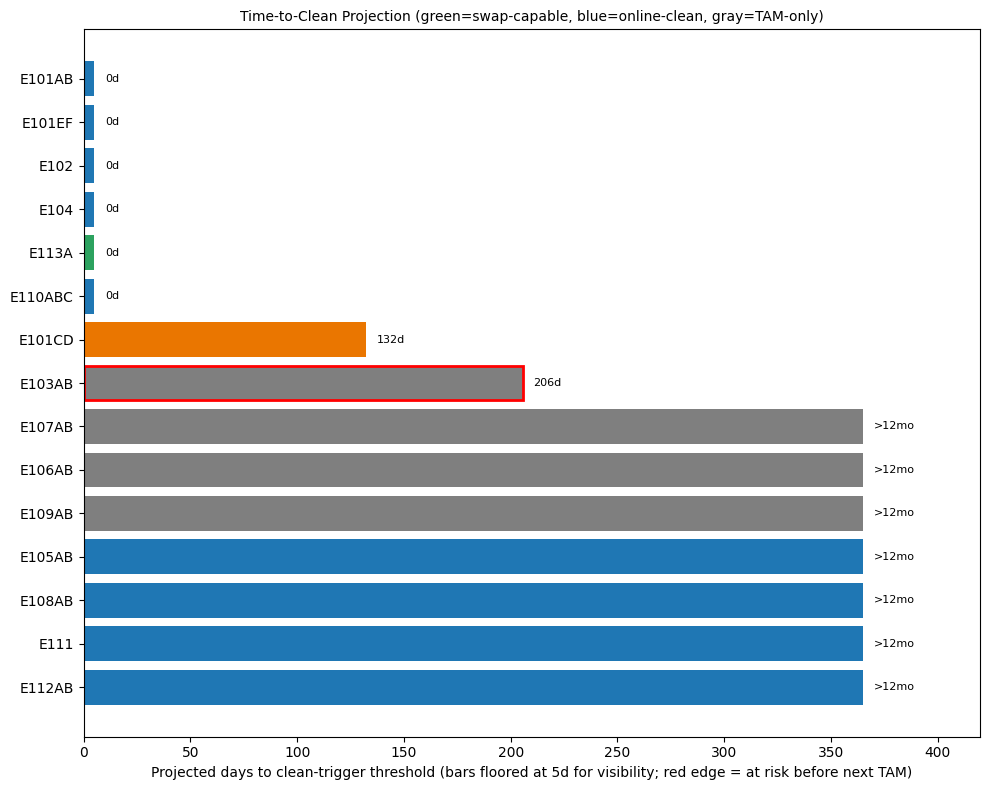

In [6]:
plot_df = result_sorted.copy()
plot_df['plot_days'] = plot_df['days_to_threshold'].fillna(HORIZON_DAYS)
DISPLAY_FLOOR = 5  # visual floor only, so "needs clean now" bars are visible -- not a real value
plot_df['plot_days_display'] = plot_df['plot_days'].clip(lower=DISPLAY_FLOOR)
tier_colors = {'SWAP_CAPABLE': '#2ca25f', 'ONLINE_FULL': '#1f77b4', 'ONLINE_PARTIAL': '#EA7600', 'TAM_ONLY': '#7f7f7f'}
colors = [tier_colors[t] for t in plot_df['effort_tier']]
risk_edge = ['red' if r else 'none' for r in plot_df['at_risk_before_tam']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(plot_df['HX'], plot_df['plot_days_display'], color=colors, edgecolor=risk_edge, linewidth=2)
for bar, days, beyond in zip(bars, plot_df['days_to_threshold'], plot_df['beyond_horizon']):
    label = '>12mo' if beyond or pd.isna(days) else f'{days:.0f}d'
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2, label, va='center', fontsize=8)
ax.set_xlabel('Projected days to clean-trigger threshold (bars floored at 5d for visibility; red edge = at risk before next TAM)')
ax.set_title('Time-to-Clean Projection (green=swap-capable, blue=online-clean, gray=TAM-only)', fontsize=10)
ax.set_xlim(0, HORIZON_DAYS * 1.15)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '3b_time_to_clean.png'), bbox_inches='tight')
plt.show()

## 5. Save Output

In [7]:
out_path = DATA_DIR + r'\Time_To_Clean_Prediction.csv'
result_sorted.to_csv(out_path, index=False)
print(f'Wrote {out_path}', result_sorted.shape)

n_at_risk = result_sorted['at_risk_before_tam'].sum()
if n_at_risk:
    print(f'\nWARNING: {n_at_risk} TAM_ONLY HX projected to need cleaning before the next TAM window:')
    print(result_sorted.loc[result_sorted['at_risk_before_tam'], ['HX', 'projected_need_by_date']])

Wrote C:\Desktop\Bangchak Internship 2026\Data\Time_To_Clean_Prediction.csv (15, 12)

       HX        projected_need_by_date
4  E103AB 2027-01-22 17:17:48.158939880


## 6. Limitations

- **Rate is a straight-line extrapolation of the current run** -- real
  fouling can accelerate (crude-quality shift, coking onset) or plateau
  (asymptotic fouling curve), neither of which a linear fit captures. Treat
  `days_to_threshold` as a planning-horizon estimate, not a guarantee.
- **Self-threshold from very few historical events is noisy** -- HX with
  only 1-2 real-clean events in the dataset have a threshold based on that
  many data points; the group-median fallback for HX with *zero* events is
  weaker still.
- **`NEXT_TAM_DATE` is a placeholder (`2028-06-01`)** -- must be replaced
  with the confirmed turnaround date before `at_risk_before_tam` flags are
  used for real scheduling decisions.
- Rate and threshold both come from the `3a` deviation signal only; `2b`'s
  independent `U_relative`/`Rf_run` trend is not cross-checked here -- `3c`
  should surface disagreement between the two as a confidence signal.